# LSTM Fall Detection — Multi-class (4 classes)

**Input**  : `data/processed/X.npy`, `y.npy`  
**Output** : `models/lstm_v2.h5`, `models/scaler_v2.pkl`, `models/report_v2.json`

| Label | Class |
|---|---|
| 0 | fall_A |
| 1 | fall_B |
| 2 | fall_C |
| 3 | non_fall |

## 1. Import & Config

In [1]:
import os, json, pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
BASE_DIR      = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
MODEL_DIR     = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

CLASS_NAMES  = ["fall_A", "fall_B", "fall_C", "non_fall"]
N_CLASSES    = 4
SEQUENCE_LEN = 10
N_FEATURES   = 416
BATCH_SIZE   = 32
EPOCHS       = 150
TEST_SIZE    = 0.15
VAL_SIZE     = 0.15
RANDOM_STATE = 42

print("Config OK")

Config OK


## 2. Load Data

In [3]:
X = np.load(os.path.join(PROCESSED_DIR, "X.npy"))
y = np.load(os.path.join(PROCESSED_DIR, "y.npy"))

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print("Class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = int(np.sum(y == i))
    pct   = count / len(y) * 100
    print(f"  {name:10s} ({i}) : {count:5d} ({pct:.1f}%)")

X shape : (29958, 416)
y shape : (29958,)
Class distribution:
  fall_A     (0) :  2020 (6.7%)
  fall_B     (1) :  8807 (29.4%)
  fall_C     (2) : 16611 (55.4%)
  non_fall   (3) :  2520 (8.4%)


## 3. Build Sequences

In [4]:
def build_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        window_labels = y[i:i + seq_len]
        if len(set(window_labels)) == 1:
            Xs.append(X[i:i + seq_len])
            ys.append(window_labels[-1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)

Xs, ys = build_sequences(X, y, SEQUENCE_LEN)
print(f"Sequences : {Xs.shape}")
print(f"Labels    : {ys.shape}")
print("Sequence class distribution:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:10s} : {int(np.sum(ys == i)):5d}")

Sequences : (29922, 10, 416)
Labels    : (29922,)
Sequence class distribution:
  fall_A     :  2011
  fall_B     :  8798
  fall_C     : 16602
  non_fall   :  2511


In [5]:
from sklearn.utils import resample

TARGET = int(np.min([np.sum(ys == i) for i in range(N_CLASSES)]))
print(f"Target per class: {TARGET}")

idx_all = []
for i in range(N_CLASSES):
    idx = np.where(ys == i)[0]
    if len(idx) > TARGET:
        idx = resample(idx, n_samples=TARGET, random_state=RANDOM_STATE, replace=False)
    idx_all.append(idx)

idx_all = np.sort(np.concatenate(idx_all))
Xs = Xs[idx_all]
ys = ys[idx_all]

print(f"Total after undersample: {len(ys)}")
print("Class distribution after undersample:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:10s} ({i}) : {int(np.sum(ys == i))}")

Target per class: 2011
Total after undersample: 8044
Class distribution after undersample:
  fall_A     (0) : 2011
  fall_B     (1) : 2011
  fall_C     (2) : 2011
  non_fall   (3) : 2011


## 4. Train / Val / Test Split

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    Xs, ys, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=ys
)
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

Train : 5,630
Val   : 1,207
Test  : 1,207


## 5. Normalize

In [7]:
scaler = StandardScaler()
_, seq_len, n_feat = X_train.shape

scaler.fit(X_train.reshape(-1, n_feat))
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(X_train.shape)
X_val   = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_test  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)

scaler_path = os.path.join(MODEL_DIR, "scaler_v2.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Normalized  scaler -> {scaler_path}")

Normalized  scaler -> /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/scaler_v2.pkl


## 6. Class Weights

In [8]:
cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
print("Class weights:")
for i, w in class_weights.items():
    print(f"  {CLASS_NAMES[i]:10s} : {w:.3f}")

y_train_cat = to_categorical(y_train, N_CLASSES)
y_val_cat   = to_categorical(y_val,   N_CLASSES)

Class weights:
  fall_A     : 1.000
  fall_B     : 1.000
  fall_C     : 1.000
  non_fall   : 1.000


## 7. Build Model

In [9]:
model = Sequential([
    LSTM(256, input_shape=(SEQUENCE_LEN, N_FEATURES), return_sequences=True, dropout=0.3),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(128, return_sequences=True, dropout=0.3),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(64, return_sequences=False, dropout=0.2),
    BatchNormalization(),

    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(N_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

2026-03-13 00:49:18.961404: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-13 00:49:18.961620: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-13 00:49:18.961636: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-13 00:49:18.961975: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-13 00:49:18.961998: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/peerawootposh/TDG/fall_detection_backend/ml_service/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argume

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 256)        │       689,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 954,308 (3.64 MB)

 Trainable params: 953,412 (3.64 MB)

 Non-trainable params: 896 (3.50 KB)

## 8. Train

In [10]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(MODEL_DIR, "lstm_v2_best.h5"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150


2026-03-13 00:49:25.541419: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3831 - loss: 1.9244
Epoch 1: val_accuracy improved from None to 0.67191, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5



Epoch 1: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.4512 - loss: 1.6638 - val_accuracy: 0.6719 - val_loss: 0.7390 - learning_rate: 1.0000e-04
Epoch 2/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5502 - loss: 1.3029
Epoch 2: val_accuracy improved from 0.67191 to 0.72162, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5



Epoch 2: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5611 - loss: 1.2361 - val_accuracy: 0.7216 - val_loss: 0.7261 - learning_rate: 1.0000e-04
Epoch 3/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5996 - loss: 1.0894
Epoch 3: val_accuracy improved from 0.72162 to 0.73902, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5


...


Epoch 76: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8698 - loss: 0.3676 - val_accuracy: 0.9089 - val_loss: 0.2746 - learning_rate: 2.5000e-05
Epoch 77/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8861 - loss: 0.3439
Epoch 77: val_accuracy did not improve from 0.90886
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8831 - loss: 0.3472 - val_accuracy: 0.9089 - val_loss: 0.2752 - learning_rate: 2.5000e-05
Epoch 78/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8735 - loss: 0.3850
Epoch 78: val_accuracy improved from 0.90886 to 0.90969, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5



Epoch 78: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8755 - loss: 0.3800 - val_accuracy: 0.9097 - val_loss: 0.2845 - learning_rate: 2.5000e-05
Epoch 79/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8682 - loss: 0.3859
Epoch 79: val_accuracy did not improve from 0.90969
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8726 - loss: 0.3731 - val_accuracy: 0.9089 - val_loss: 0.2774 - learning_rate: 2.5000e-05
Epoch 80/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8803 - loss: 0.3588
Epoch 80: val_accuracy did not improve from 0.90969
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8767 - loss: 0.3670 - val_accuracy: 0.9072 - val_loss: 0.2787 - learning_rate: 2.5000e-05
Epoch 81/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8794 - loss: 0.3406
Epoch 81: val_accuracy improved from 0.90969 to 0.91301, saving model to 


Epoch 81: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8790 - loss: 0.3489 - val_accuracy: 0.9130 - val_loss: 0.2701 - learning_rate: 2.5000e-05
Epoch 82/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8636 - loss: 0.4026
Epoch 82: val_accuracy did not improve from 0.91301
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8696 - loss: 0.3892 - val_accuracy: 0.9114 - val_loss: 0.2682 - learning_rate: 2.5000e-05
Epoch 83/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8733 - loss: 0.3835
Epoch 83: val_accuracy did not improve from 0.91301
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8744 - loss: 0.3738 - val_accuracy: 0.9114 - val_loss: 0.2694 - learning_rate: 2.5000e-05
Epoch 84/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8745 - loss: 0.3734
Epoch 84: val_accuracy did not improve from 0.91301
176/176 ━━━━━━━━━━━━━


Epoch 86: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8734 - loss: 0.3624 - val_accuracy: 0.9155 - val_loss: 0.2621 - learning_rate: 2.5000e-05
Epoch 87/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8745 - loss: 0.3495
Epoch 87: val_accuracy did not improve from 0.91549
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8748 - loss: 0.3638 - val_accuracy: 0.9138 - val_loss: 0.2573 - learning_rate: 2.5000e-05
Epoch 88/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8817 - loss: 0.3454
Epoch 88: val_accuracy improved from 0.91549 to 0.91715, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5



Epoch 88: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2_best.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8767 - loss: 0.3625 - val_accuracy: 0.9171 - val_loss: 0.2699 - learning_rate: 2.5000e-05
Epoch 89/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8794 - loss: 0.3617
Epoch 89: val_accuracy did not improve from 0.91715
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8813 - loss: 0.3662 - val_accuracy: 0.9122 - val_loss: 0.2632 - learning_rate: 2.5000e-05
Epoch 90/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8833 - loss: 0.3430
Epoch 90: val_accuracy did not improve from 0.91715
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8737 - loss: 0.3709 - val_accuracy: 0.9163 - val_loss: 0.2618 - learning_rate: 2.5000e-05
Epoch 91/150
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8782 - loss: 0.3762
Epoch 91: val_accuracy did not improve from 0.91715
176/176 ━━━━━━━━━━━━━

## 9. History

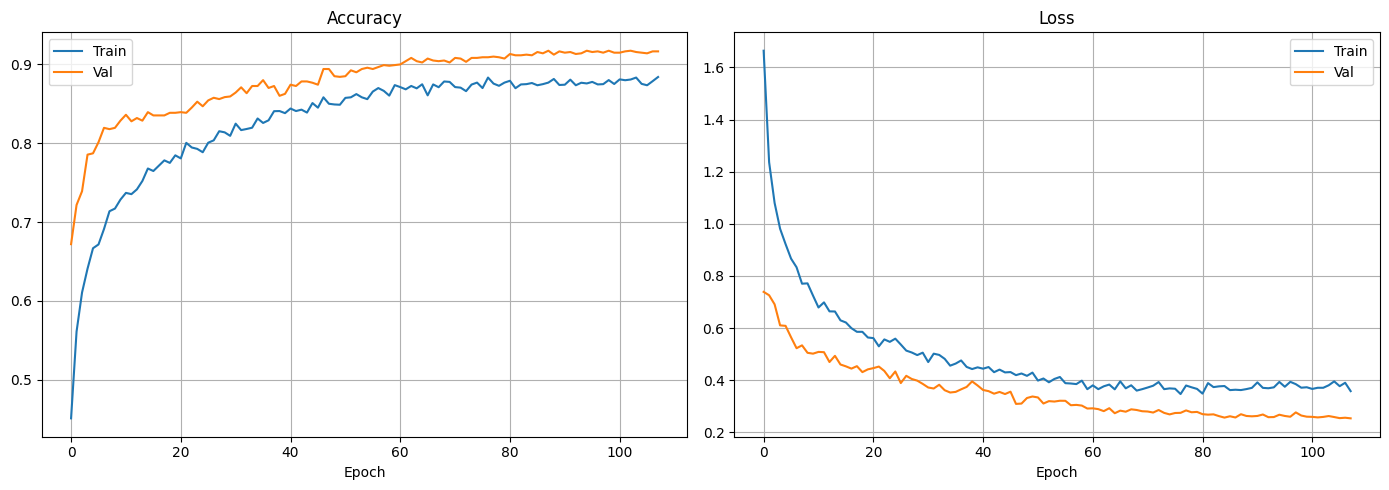

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history.history[metric],          label="Train")
    ax.plot(history.history[f"val_{metric}"], label="Val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "history_v2.png"), dpi=150)
plt.show()

## 10. Evaluate

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

      fall_A       0.97      1.00      0.99       302
      fall_B       0.93      0.97      0.95       301
      fall_C       0.91      0.83      0.87       302
    non_fall       0.90      0.91      0.91       302

    accuracy                           0.93      1207
   macro avg       0.93      0.93      0.93      1207
weighted avg       0.93      0.93      0.93      1207



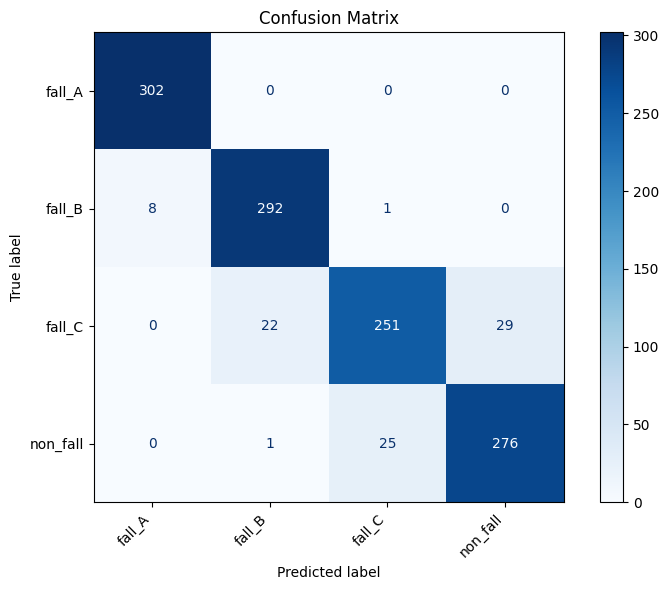

In [12]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "confusion_v2.png"), dpi=150)
plt.show()

## 11. Save

In [13]:
model_path = os.path.join(MODEL_DIR, "lstm_v2.h5")
model.save(model_path)

report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
report_data = {
    "created_at":    datetime.now().isoformat(),
    "n_classes":     N_CLASSES,
    "class_names":   CLASS_NAMES,
    "sequence_len":  SEQUENCE_LEN,
    "n_features":    N_FEATURES,
    "train_samples": int(X_train.shape[0]),
    "val_samples":   int(X_val.shape[0]),
    "test_samples":  int(X_test.shape[0]),
    "test_accuracy": float(report["accuracy"]),
    "class_report":  report,
}
with open(os.path.join(MODEL_DIR, "report_v2.json"), "w") as f:
    json.dump(report_data, f, indent=2, ensure_ascii=False)

print(f"model  -> {model_path}")
print(f"Test Accuracy : {report['accuracy']*100:.1f}%")

model  -> /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v2.h5
Test Accuracy : 92.9%
